# Beginner Starter Notebook

Welcome to the Urban Micro-Mobility Demand Forecasting competition.

This notebook provides a complete, end-to-end baseline pipeline. It demonstrates how to load the data, handle categorical variables using one-hot encoding, train a standard Linear Regression model, and generate a valid submission file.

### Objective
Our goal is to predict the `Rented_Bike_Count` for a given hour.

**Important Note:** As stated in the competition rules, the target variable in `train.csv` has already been `log1p` transformed to stabilize the variance of extreme demand spikes. Because the evaluation metric is Root Mean Squared Error (RMSE), we will train our model directly on this provided target and submit our predictions on this same logarithmic scale.

In [33]:
# Step 1: Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge, SGDRegressor
from sklearn.metrics import root_mean_squared_error

# Set plotting style for formal aesthetic
plt.style.use('ggplot')
sns.set_theme(style="whitegrid")

import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully.")

Libraries imported successfully.


In [34]:
# Step 2: Load the Datasets

# Load the training and testing data
# Note: Ensure the file paths match your Kaggle environment directory structure
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

print(f"Training data shape: {train_df.shape}")
print(f"Testing data shape: {test_df.shape}")

# Display the first few rows of the training set
display(train_df.head())

Training data shape: (6576, 15)
Testing data shape: (2184, 14)


,Id,Date,Rented_Bike_Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,0,01/12/2017,5.541264,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,1,01/12/2017,5.323010,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,2,01/12/2017,5.159055,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,3,01/12/2017,4.682131,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,4,01/12/2017,4.369448,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


### Brief Exploratory Data Analysis (EDA)
Before modeling, let us visualize the relationship between the time of day and the rental demand. Note that the y-axis represents the `log1p` transformed demand, not the raw count of bikes.

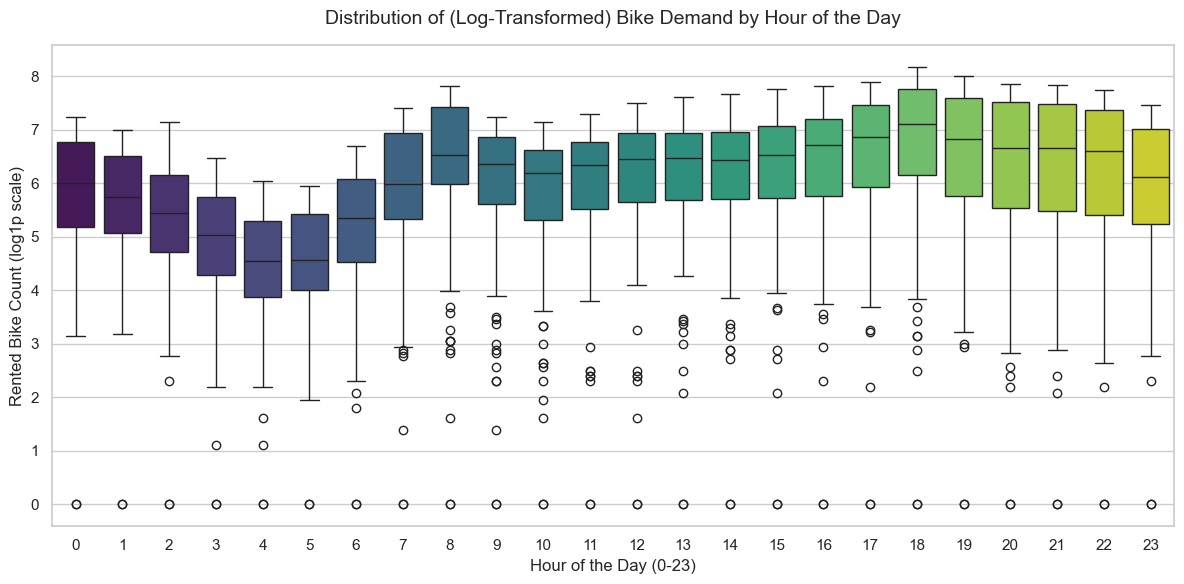

In [35]:
# Step 3: Visualize Target Distribution by Hour

plt.figure(figsize=(12, 6))
sns.boxplot(data=train_df, x='Hour', y='Rented_Bike_Count', palette='viridis')

plt.title('Distribution of (Log-Transformed) Bike Demand by Hour of the Day', fontsize=14, pad=15)
plt.xlabel('Hour of the Day (0-23)', fontsize=12)
plt.ylabel('Rented Bike Count (log1p scale)', fontsize=12)
plt.tight_layout()
plt.show()

# Insight: Notice the distinct peaks around 8 AM (morning commute) and 6 PM (evening commute).

### Data Preprocessing
Machine learning models require numerical input. We need to convert our text-based categorical columns (`Seasons`, `Holiday`, `Functioning Day`) into a numerical format using One-Hot Encoding. This process creates new binary columns (0 or 1) for each category.

*Challenge for you:* We are currently dropping the `Date` column to keep this baseline simple. Can you figure out how to extract the `Month` or `Day_of_Week` from it before dropping it?

In [36]:
# Step 4: Data Preprocessing

def preprocess_data(df, is_train=True):
    data = df.copy()

    # Separate target variable if this is the training set
    if is_train:
        y = data['Rented_Bike_Count']
    else:
        y = None

    # Drop categorical columns entirely, plus 'Date' and 'Id'
    # We only keep the raw numerical columns provided in the dataset
    cols_to_drop = ['Id', 'Date', 'Seasons', 'Holiday', 'Functioning Day']
    features = data.drop(columns=cols_to_drop)

    # If this is train, also drop the target from the features
    if is_train:
        features = features.drop(columns=['Rented_Bike_Count'])

    return features, y

# Apply the naive preprocessing
X, y = preprocess_data(train_df, is_train=True)
X_test, _ = preprocess_data(test_df, is_train=False)

print(f"Processed feature matrix shape (numeric only): {X.shape}")

Processed feature matrix shape (numeric only): (6576, 9)


### Model Training & Validation
We will use a standard Multiple Linear Regression model. This algorithm will attempt to find the best-fitting linear relationship between our input features (like temperature, hour, and seasons) and our target demand.

In [39]:
# Step 5: Validation Split and Model Training

# Split the training data into local train and validation sets (80/20 split)
# Note: For time-series data, a chronological split is usually better than a random split.
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the standard Linear Regression model
model = Lasso(alpha=1)
model.fit(X_train, y_train)

# Predict on the local validation set
val_predictions = model.predict(X_val)

# Calculate and print the Root Mean Squared Error (RMSE)
val_rmse = root_mean_squared_error(y_val, val_predictions)
print(f"Local Validation RMSE: {val_rmse:.4f}")

Local Validation RMSE: 1.0204


### Creating the Submission File
Now that our model is trained, we will generate predictions for the `test.csv` dataset and format them according to Kaggle's requirements.

In [38]:
# Step 6: Generate Final Predictions and Export

# Generate predictions on the preprocessed test set
test_predictions = model.predict(X_test)

# Create the submission dataframe
submission = pd.DataFrame({
    'Id': test_df['Id'],
    'Rented_Bike_Count': test_predictions
})

# Display the first few rows of the submission
display(submission.head())

# Export to CSV (without the pandas index)
submission.to_csv('submission10.csv', index=False)
print("Submission successfully saved as 'submission.csv'.")
print("You are ready to submit to the Kaggle Leaderboard.")

,Id,Rented_Bike_Count
0,6576,5.786863
1,6577,5.799036
2,6578,5.727620
3,6579,5.716296
4,6580,5.686322


Submission successfully saved as 'submission.csv'.
You are ready to submit to the Kaggle Leaderboard.
